# RDD Paper Figures

This notebook generates paper-ready plots:
- Accuracy curves (linear only) for sampling, curriculum, supervision
- Confusion matrices for teacher and student models


In [21]:
import csv
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.metrics import confusion_matrix

from models import model_dict
from dataset.cifar100 import get_cifar100_dataloaders

sns.set_theme(style='whitegrid', font='serif', font_scale=1.1)
plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

DATA_PATH = Path('save/tensorboard_export/experiments.csv')
FIG_PATH = Path('save/tensorboard_export')
FIG_PATH.mkdir(parents=True, exist_ok=True)


In [22]:
RUN_LABELS = {
    # Baselines
    'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_1': 'KD (baseline)',
    'S:resnet8x4_T:resnet32x4_cifar100_crd_r:1_a:0.0_b:0.8_1': 'CRD (baseline)',
    'S:resnet8x4_T:resnet32x4_cifar100_rkd_r:1_a:0.0_b:1.0_1': 'RKD (baseline)',

    # RDD variants
    'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_rdx0.15_2': 'RDD Sampling',
    'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_curr0.3-100e_3': 'RDD Curriculum',
    'S:resnet8x4_T:resnet32x4_cifar100_rdx_contrast_r:1_a:0.0_b:0.8_2': 'RDD Supervision (contrast)',
}

COLORS = {
    'KD (baseline)': '#2d2d2d',
    'CRD (baseline)': '#e74c3c',
    'RKD (baseline)': '#7f8c8d',
    'RDD Sampling': '#3498db',
    'RDD Curriculum': '#27ae60',
    'RDD Supervision (contrast)': '#9b59b6',
}

LINESTYLES = {
    'KD (baseline)': '-',
    'CRD (baseline)': '-',
    'RKD (baseline)': '--',
    'RDD Sampling': '-',
    'RDD Curriculum': '-',
    'RDD Supervision (contrast)': '-',
}

GROUPS = {
    'sampling': ['KD (baseline)', 'CRD (baseline)', 'RKD (baseline)', 'RDD Sampling'],
    'curriculum': ['KD (baseline)', 'CRD (baseline)', 'RKD (baseline)', 'RDD Curriculum'],
    'supervision': ['KD (baseline)', 'CRD (baseline)', 'RKD (baseline)', 'RDD Supervision (contrast)'],
}

SMOOTH = 0.6

rows = []
with open(DATA_PATH) as f:
    r = csv.DictReader(f)
    for row in r:
        label = RUN_LABELS.get(row['run'])
        if label:
            rows.append({
                'label': label,
                'step': int(row['step']),
                'tag': row['tag'],
                'value': float(row['value'])
            })


def pivot_run(rows, tag):
    out = defaultdict(list)
    for r in rows:
        if r['tag'] == tag:
            out[r['label']].append((r['step'], r['value']))
    return {k: (tuple(zip(*sorted(v)))) for k, v in out.items()}


def smooth_curve(steps, values, alpha=0.6):
    vals = list(values)
    if not vals:
        return steps, vals
    smoothed = [vals[0]]
    for i in range(1, len(vals)):
        smoothed.append(alpha * smoothed[-1] + (1 - alpha) * vals[i])
    return steps, smoothed


test_acc = pivot_run(rows, 'test_acc')
print('Loaded', len(rows), 'rows. Runs:', list(test_acc.keys()))


Loaded 7200 rows. Runs: ['CRD (baseline)', 'KD (baseline)', 'RDD Curriculum', 'RDD Sampling', 'RDD Supervision (contrast)', 'RKD (baseline)']


In [23]:
# Display final test accuracy per run
final_acc = {}
for label, (steps, vals) in test_acc.items():
    if not vals:
        continue
    final_acc[label] = vals[-1]

print('Final test accuracy (last logged epoch):')
for label in GROUPS['sampling'] + GROUPS['curriculum'] + GROUPS['supervision']:
    if label in final_acc:
        print(f"  {label}: {final_acc[label]:.2f}")


Final test accuracy (last logged epoch):
  KD (baseline): 72.93
  CRD (baseline): 75.45
  RKD (baseline): 71.55
  RDD Sampling: 59.49
  KD (baseline): 72.93
  CRD (baseline): 75.45
  RKD (baseline): 71.55
  RDD Curriculum: 72.96
  KD (baseline): 72.93
  CRD (baseline): 75.45
  RKD (baseline): 71.55
  RDD Supervision (contrast): 75.58


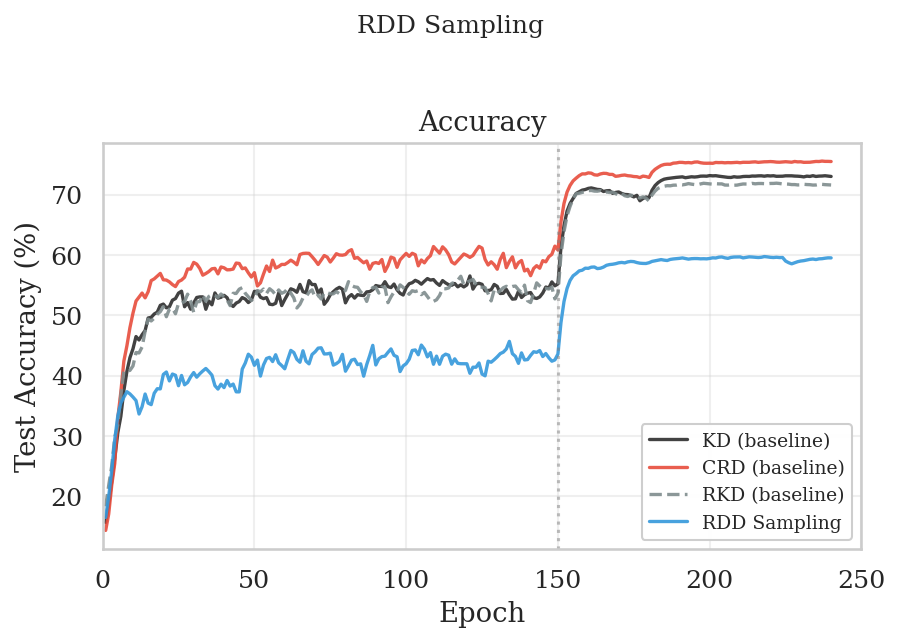

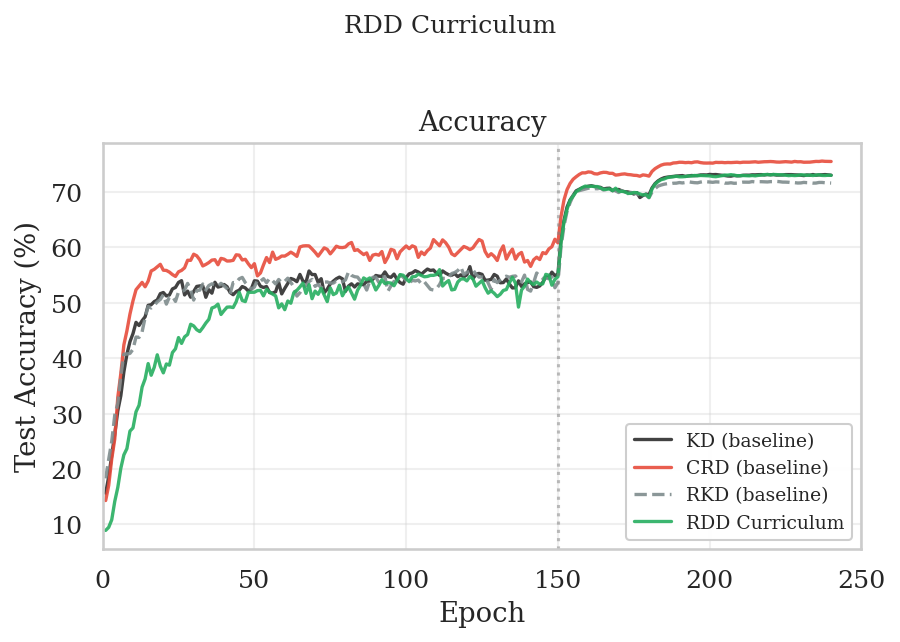

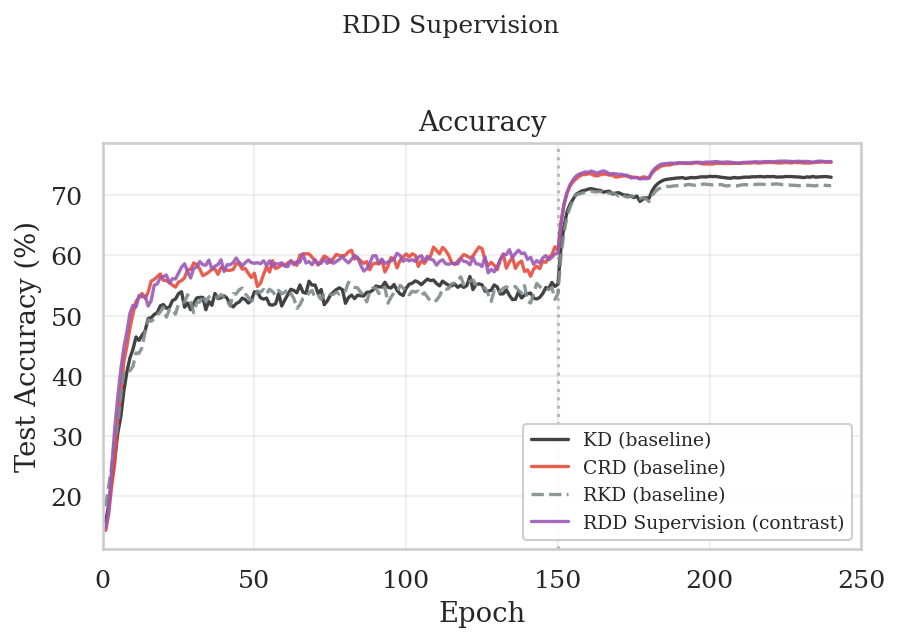

In [24]:
def plot_accuracy(labels, title, out_prefix):
    fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.2))

    for label in labels:
        if label not in test_acc:
            continue
        steps, vals = smooth_curve(*test_acc[label], alpha=SMOOTH)
        ax.plot(steps, vals, label=label, color=COLORS.get(label),
                linestyle=LINESTYLES.get(label, '-'), linewidth=1.6, alpha=0.9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Accuracy')
    ax.legend(loc='lower right', framealpha=0.95, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 250)
    ax.axvline(150, color='gray', linestyle=':', alpha=0.5)

    fig.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_PATH / f'{out_prefix}.pdf')
    plt.savefig(FIG_PATH / f'{out_prefix}.png')
    plt.show()


plot_accuracy(GROUPS['sampling'], 'RDD Sampling', 'fig_sampling')
plot_accuracy(GROUPS['curriculum'], 'RDD Curriculum', 'fig_curriculum')
plot_accuracy(GROUPS['supervision'], 'RDD Supervision', 'fig_supervision')


[skip] missing checkpoint for KD (baseline): S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_1
Computing confusion matrix for Teacher...
Computing confusion matrix for CRD (baseline)...
Computing confusion matrix for RKD (baseline)...
Computing confusion matrix for RDD Sampling...
Computing confusion matrix for RDD Curriculum...
Computing confusion matrix for RDD Supervision (contrast)...


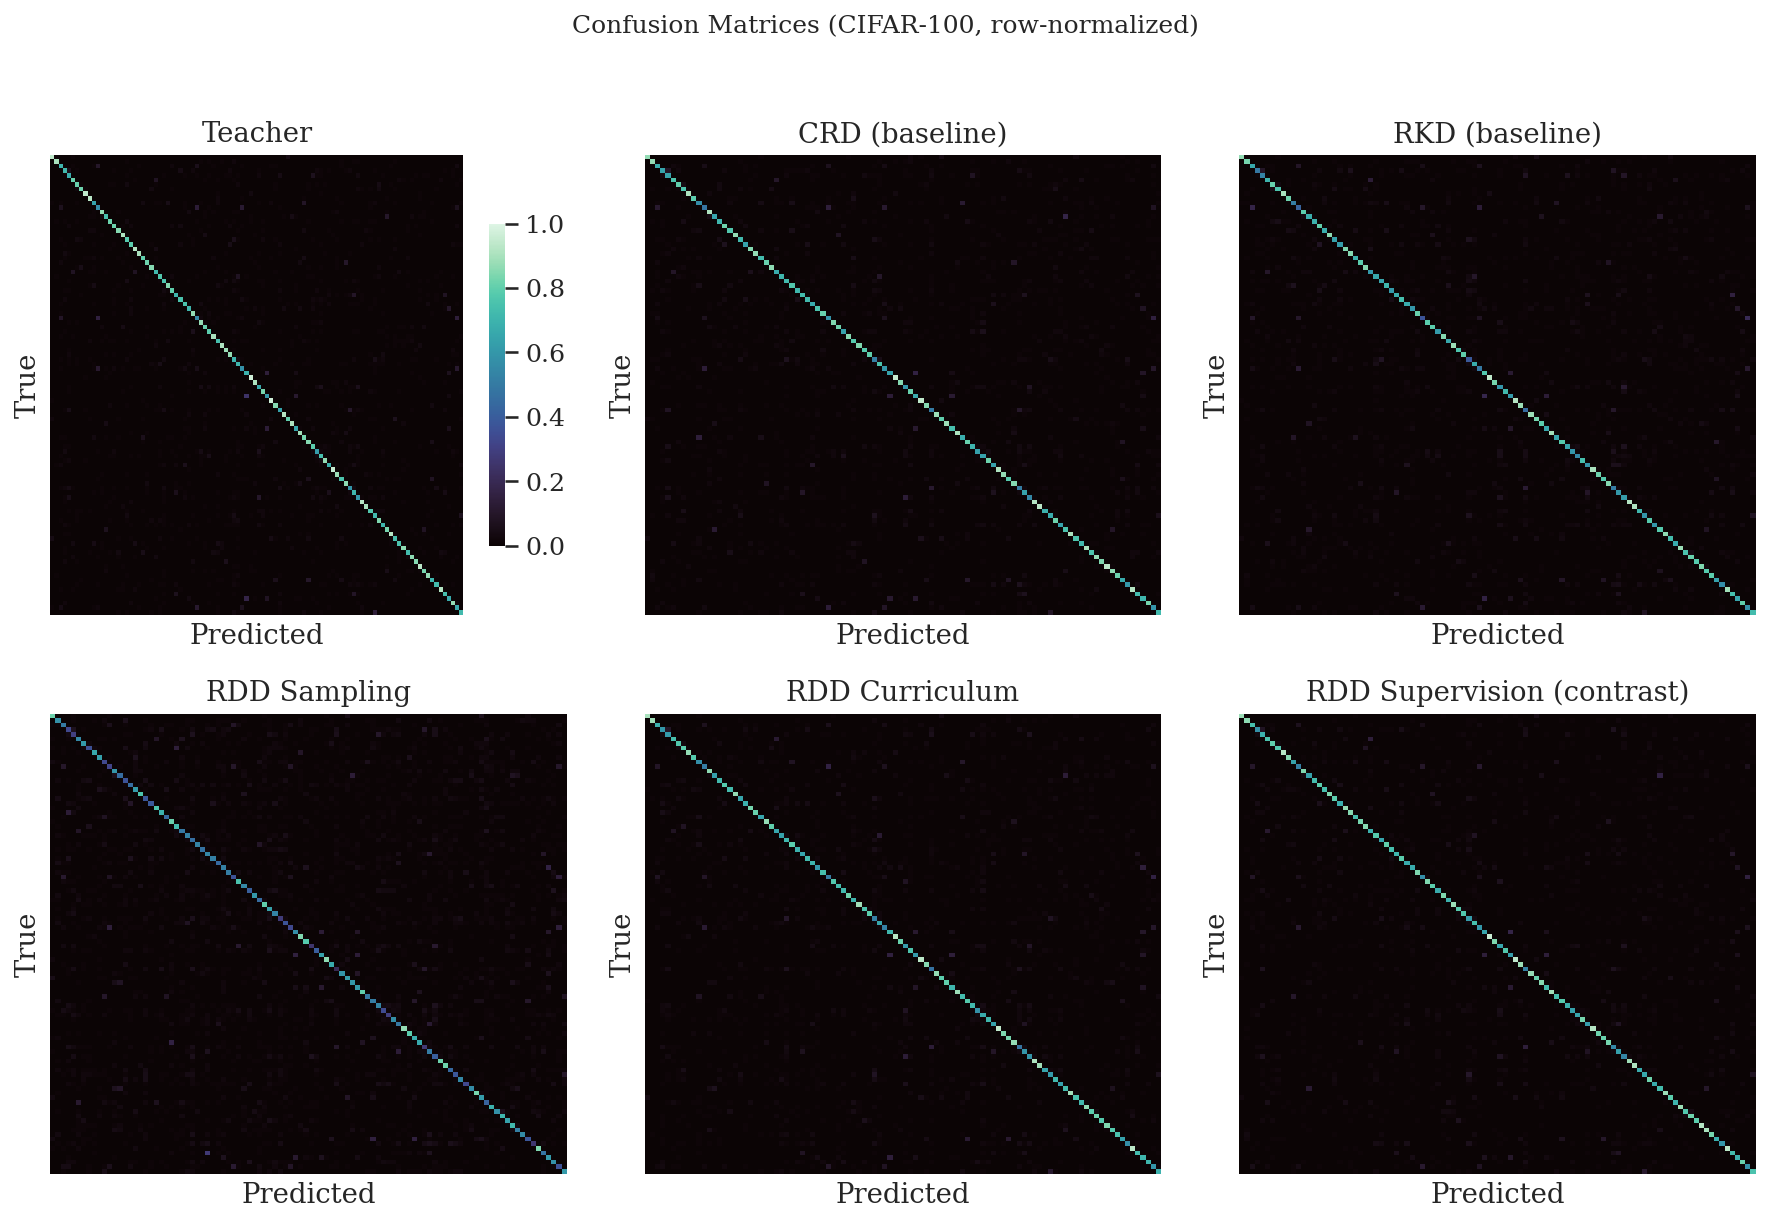

In [18]:
# Confusion matrices (teacher + baselines + RDD variants)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def resolve_checkpoint(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.exists():
        return None
    for name in ['resnet8x4_best.pth', 'resnet8x4_last.pth', 'ckpt_epoch_240.pth']:
        candidate = run_dir / name
        if candidate.exists():
            return candidate
    ckpts = sorted(run_dir.glob('ckpt_epoch_*.pth'))
    return ckpts[-1] if ckpts else None


def load_model(model_name, ckpt_path):
    model = model_dict[model_name](num_classes=100)
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(state['model'])
    model.to(DEVICE)
    model.eval()
    return model


def compute_confusion(model, loader, num_classes=100):
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in loader:
            x, y = batch[0], batch[1]
            x = x.float().to(DEVICE)
            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            y_true.append(y.numpy())
            y_pred.append(pred)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize='true')
    return cm


STUDENT_RUNS = {
    'KD (baseline)': 'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_1',
    'CRD (baseline)': 'S:resnet8x4_T:resnet32x4_cifar100_crd_r:1_a:0.0_b:0.8_1',
    'RKD (baseline)': 'S:resnet8x4_T:resnet32x4_cifar100_rkd_r:1_a:0.0_b:1.0_1',
    'RDD Sampling': 'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_rdx0.15_2',
    'RDD Curriculum': 'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_curr0.3-100e_3',
    'RDD Supervision (contrast)': 'S:resnet8x4_T:resnet32x4_cifar100_rdx_contrast_r:1_a:0.0_b:0.8_2',
}

TEACHER_CKPT = Path('save/models/resnet32x4_vanilla/ckpt_epoch_240.pth')
STUDENT_ROOT = Path('save/student_model')

_, test_loader = get_cifar100_dataloaders(batch_size=256, num_workers=4, is_instance=False)

# Load teacher
models = []
teacher = load_model('resnet32x4', TEACHER_CKPT)
models.append(('Teacher', teacher))

# Load students
for label, run_name in STUDENT_RUNS.items():
    ckpt = resolve_checkpoint(STUDENT_ROOT / run_name)
    if ckpt is None:
        print(f'[skip] missing checkpoint for {label}: {run_name}')
        continue
    m = load_model('resnet8x4', ckpt)
    models.append((label, m))

# Compute confusion matrices
confusions = {}
for label, model in models:
    print(f'Computing confusion matrix for {label}...')
    confusions[label] = compute_confusion(model, test_loader, num_classes=100)

# Plot grid
names = list(confusions.keys())
cols = 3
rows = int(np.ceil(len(names) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(rows, cols)

for i, name in enumerate(names):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    sns.heatmap(confusions[name], ax=ax, cmap='mako', vmin=0.0, vmax=1.0,
                cbar=(i == 0), cbar_kws={'shrink': 0.7})
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([])
    ax.set_yticks([])

# Hide empty panels
for j in range(i + 1, rows * cols):
    r, c = divmod(j, cols)
    axes[r, c].axis('off')

fig.suptitle('Confusion Matrices (CIFAR-100, row-normalized)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH / 'fig_confusion_grid.pdf')
plt.savefig(FIG_PATH / 'fig_confusion_grid.png')
plt.show()
